# Attention Is All You Need: The Transformer

This notebook walks through the most influential machine learning paper of the decade —
**"Attention Is All You Need"** (Vaswani et al., 2017). The Transformer architecture
introduced here is the foundation for GPT, BERT, LLaMA, Stable Diffusion, AlphaFold,
and virtually every modern AI system.

We will:
1. Understand why RNNs and CNNs were insufficient for sequence modeling
2. Build scaled dot-product attention and multi-head attention from scratch
3. Implement positional encoding, the feed-forward network, and layer normalization
4. Assemble the full encoder-decoder Transformer
5. Connect to modern variants: what changed since 2017

**Reference:** Vaswani, A. et al. (2017). *Attention Is All You Need.* NeurIPS 2017.
https://arxiv.org/abs/1706.03762

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import matplotlib.pyplot as plt
from src.utils.device import set_seed

set_seed(42)
print(f"PyTorch version: {torch.__version__}")

Set seed for reproducibility: 42
PyTorch version: 2.11.0


## 1. The Sequence Modeling Problem

Before Transformers, sequence modeling was dominated by RNNs and CNNs:

| | RNN/LSTM | CNN | **Transformer** |
|---|---|---|---|
| Long-range dependencies | Weak (vanishing gradients) | Weak (local receptive field) | **Strong (direct attention)** |
| Parallelization | None (sequential) | Full | **Full** |
| Path length for token i→j | $O(n)$ steps | $O(\log n)$ layers | **$O(1)$ — direct** |
| Computation per layer | $O(n \cdot d^2)$ | $O(k \cdot n \cdot d^2)$ | $O(n^2 \cdot d)$ |

The key limitation of RNNs: to get information from token 1 to token 100, it must pass
through 99 sequential steps. Gradients vanish, and the model forgets.

**The Transformer's radical idea:** Replace recurrence entirely with attention.
Any token can attend directly to any other token in a single step.

## 2. Why Attention?

The paper's title is a bold claim: attention is **all** you need. No recurrence, no
convolutions — just attention, feed-forward layers, and normalization.

Attention computes a weighted sum of values, where the weights come from comparing
queries against keys. This allows:
- **Direct connections** between any two positions (no information bottleneck)
- **Full parallelization** (no sequential dependency)
- **Interpretable weights** (we can see what the model attends to)

In [2]:
# Illustrate: RNN is sequential, attention is parallel

# RNN: must process tokens one at a time
def rnn_process(tokens, hidden_size=8):
    """Simulates RNN: each step depends on the previous."""
    h = torch.zeros(hidden_size)
    W_h = torch.randn(hidden_size, hidden_size) * 0.1
    W_x = torch.randn(hidden_size, tokens.shape[-1]) * 0.1
    steps = 0
    for t in range(tokens.shape[0]):  # must be sequential!
        h = torch.tanh(W_h @ h + W_x @ tokens[t])
        steps += 1
    return h, steps

# Attention: processes all tokens at once
def attention_process(tokens, d=8):
    """Simulates attention: all pairs computed in parallel."""
    Q = K = V = tokens  # simplified self-attention
    scores = Q @ K.T / math.sqrt(d)  # all pairs at once!
    weights = torch.softmax(scores, dim=-1)
    output = weights @ V
    return output

tokens = torch.randn(10, 8)  # 10 tokens, 8 dims
_, rnn_steps = rnn_process(tokens)
attn_out = attention_process(tokens)

print(f"RNN: {rnn_steps} sequential steps to process {len(tokens)} tokens")
print(f"Attention: 1 matrix multiply to process {len(tokens)} tokens (all pairs)")
print(f"\nFor 1000 tokens: RNN needs 1000 steps, Attention still needs 1 matmul")

RNN: 10 sequential steps to process 10 tokens
Attention: 1 matrix multiply to process 10 tokens (all pairs)

For 1000 tokens: RNN needs 1000 steps, Attention still needs 1 matmul


## 3. Scaled Dot-Product Attention

The core operation of the Transformer:

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$

- $Q$ (queries), $K$ (keys), $V$ (values) are linear projections of the input
- $QK^T$ computes similarity between every pair of tokens
- Softmax normalizes to get attention weights (sum to 1 per row)
- Multiply by $V$ to get the output: a weighted combination of values

**Why scale by $\sqrt{d_k}$?** Without scaling, dot products grow proportionally to $d_k$.
For large $d_k$, some softmax inputs become very large, pushing gradients to near-zero
(saturation). Dividing by $\sqrt{d_k}$ keeps the variance of the dot products at ~1.

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention (Equation 1 from the paper).
    
    Args:
        Q: [batch, seq_q, d_k]
        K: [batch, seq_k, d_k]
        V: [batch, seq_k, d_v]
        mask: optional mask [batch, seq_q, seq_k] (True = mask out)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)  # [batch, seq_q, seq_k]

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = torch.softmax(scores, dim=-1)  # [batch, seq_q, seq_k]
    output = weights @ V                      # [batch, seq_q, d_v]
    return output, weights


# Demo
Q = torch.randn(1, 4, 8)  # 4 queries, d_k=8
K = torch.randn(1, 4, 8)  # 4 keys
V = torch.randn(1, 4, 8)  # 4 values

output, weights = scaled_dot_product_attention(Q, K, V)
print(f"Q shape: {Q.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights (each row sums to 1):")
print(f"{weights[0].detach().numpy().round(3)}")
print(f"Row sums: {weights[0].sum(dim=-1).detach().numpy().round(3)}")

Q shape: torch.Size([1, 4, 8])
Output shape: torch.Size([1, 4, 8])
Attention weights (each row sums to 1):
[[0.093 0.173 0.257 0.477]
 [0.605 0.089 0.248 0.058]
 [0.314 0.067 0.561 0.059]
 [0.179 0.076 0.672 0.073]]
Row sums: [1. 1. 1. 1.]


## 4. Multi-Head Attention

The paper's key innovation: instead of one attention function with $d_{model}$ dimensions,
use $h$ parallel attention "heads" with $d_k = d_{model} / h$ dimensions each.

$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$

where $\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

**Why multiple heads?** Each head operates in a different subspace and can learn
different attention patterns:
- Head 1 might attend to the previous word (local syntax)
- Head 2 might attend to the subject of the sentence (long-range semantics)
- Head 3 might attend to punctuation (structure)

The paper uses $h = 8$ heads with $d_k = d_v = d_{model}/h = 64$.

In [4]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention (Section 3.2.2 of the paper)."""

    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        # Project and reshape: [batch, seq, d_model] → [batch, heads, seq, d_k]
        Q = self.W_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # Attention per head
        if mask is not None:
            mask = mask.unsqueeze(1)  # broadcast over heads
        output, weights = scaled_dot_product_attention(Q, K, V, mask)

        # Concatenate heads: [batch, heads, seq, d_k] → [batch, seq, d_model]
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(output), weights


# Demo
mha = MultiHeadAttention(d_model=32, n_heads=4)
x = torch.randn(1, 6, 32)  # 6 tokens, d_model=32
output, weights = mha(x, x, x)  # self-attention

print(f"Input:  {x.shape}")
print(f"Output: {output.shape}")
print(f"Attention weights: {weights.shape} (batch, heads, seq_q, seq_k)")
print(f"Parameters: {sum(p.numel() for p in mha.parameters()):,}")

Input:  torch.Size([1, 6, 32])
Output: torch.Size([1, 6, 32])
Attention weights: torch.Size([1, 4, 6, 6]) (batch, heads, seq_q, seq_k)
Parameters: 4,224


## 5. Position-wise Feed-Forward Network

After attention, each position passes through the same two-layer MLP:

$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$

- Inner dimension is 4x the model dimension: $d_{ff} = 4 \times d_{model} = 2048$
- Applied independently to each token position ("position-wise")
- ReLU activation in the paper (modern LLMs use SwiGLU or GELU)

**Why is this needed?** Attention computes a weighted average — it's linear in $V$.
The FFN adds the **nonlinearity** that lets the model compute complex functions.

In [5]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network (Section 3.3)."""

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


ff = FeedForward(d_model=32, d_ff=128)
x = torch.randn(1, 6, 32)
print(f"FFN: {x.shape} → {ff(x).shape}")
print(f"Inner dimension: 32 → 128 → 32 (4x expansion)")

FFN: torch.Size([1, 6, 32]) → torch.Size([1, 6, 32])
Inner dimension: 32 → 128 → 32 (4x expansion)


## 6. Positional Encoding

Attention is permutation-invariant — it doesn't know token order. The paper adds
**sinusoidal positional encodings** to the input embeddings:

$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$

$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$

**Why sinusoidal?** The authors hypothesized that the model could learn to attend
to relative positions, since $PE_{pos+k}$ can be represented as a linear function of
$PE_{pos}$ for any fixed offset $k$.

**Modern alternative:** RoPE (see `05_Papers/02_RoPE.ipynb`) rotates Q/K instead of
adding to embeddings, and encodes relative position more directly.

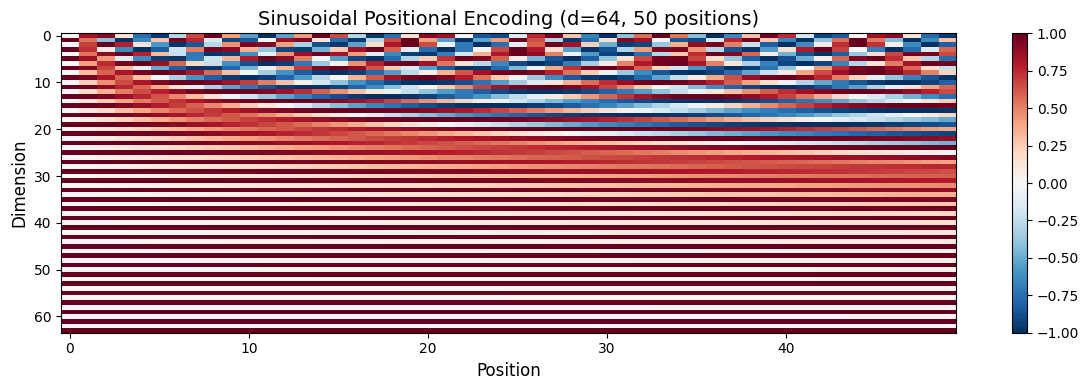

Low dimensions (bottom) → high frequency → encode local position
High dimensions (top) → low frequency → encode global position


In [6]:
class PositionalEncoding(nn.Module):
    """Sinusoidal Positional Encoding (Section 3.5)."""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        x = x + self.pe[:, :x.shape[1]]
        return self.dropout(x)


# Visualize the positional encoding pattern
pe = PositionalEncoding(d_model=64, max_len=100, dropout=0.0)
encoding = pe.pe[0, :50, :].numpy()  # first 50 positions

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(encoding.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Dimension', fontsize=12)
ax.set_title('Sinusoidal Positional Encoding (d=64, 50 positions)', fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("Low dimensions (bottom) → high frequency → encode local position")
print("High dimensions (top) → low frequency → encode global position")

## 7. The Encoder

The encoder is a stack of $N = 6$ identical layers. Each layer has two sub-layers:

1. **Multi-head self-attention** — each token attends to all tokens in the input
2. **Position-wise feed-forward network** — independent nonlinear transformation

Each sub-layer has a **residual connection** and **layer normalization**:

$\text{output} = \text{LayerNorm}(x + \text{SubLayer}(x))$

**Why LayerNorm?** BatchNorm normalizes across the batch dimension, which doesn't work
well for variable-length sequences. LayerNorm normalizes across the feature dimension
for each token independently.

**Note:** The paper uses **post-norm** (norm after residual). Modern LLMs use **pre-norm**
(norm before the sub-layer) — it's more stable for deep models.

In [7]:
class EncoderLayer(nn.Module):
    """One encoder layer (Section 3.1)."""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention + residual + norm (post-norm, as in the paper)
        attn_out, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        # FFN + residual + norm
        ff_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x


class Encoder(nn.Module):
    """Stack of N encoder layers."""

    def __init__(self, d_model, n_heads, d_ff, n_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x


enc = Encoder(d_model=32, n_heads=4, d_ff=128, n_layers=2)
x = torch.randn(1, 6, 32)
print(f"Encoder: {x.shape} → {enc(x).shape}")
print(f"Parameters: {sum(p.numel() for p in enc.parameters()):,}")

Encoder: torch.Size([1, 6, 32]) → torch.Size([1, 6, 32])
Parameters: 25,408


## 8. The Decoder

The decoder also has $N = 6$ layers, but each has **three** sub-layers:

1. **Masked self-attention** — each token attends only to previous tokens (causal mask)
2. **Cross-attention** — decoder attends to the encoder output (queries from decoder, keys/values from encoder)
3. **Feed-forward network** — same as encoder

**Why masked self-attention?** During generation, the model predicts one token at a time.
Token $t$ should only see tokens $1, ..., t-1$ — not future tokens. The causal mask
sets future positions to $-\infty$ before softmax, making their weights zero.

In [8]:
class DecoderLayer(nn.Module):
    """One decoder layer (Section 3.1)."""

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # Masked self-attention
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Cross-attention (query from decoder, key/value from encoder)
        cross_out, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(cross_out))
        # FFN
        ff_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x


# Show the causal mask
seq_len = 6
causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
print("Causal mask (True = masked, can't attend to future):")
print(causal_mask.int().numpy())
print("\nRow 0 can only see position 0")
print("Row 3 can see positions 0, 1, 2, 3")

Causal mask (True = masked, can't attend to future):
[[0 1 1 1 1 1]
 [0 0 1 1 1 1]
 [0 0 0 1 1 1]
 [0 0 0 0 1 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]

Row 0 can only see position 0
Row 3 can see positions 0, 1, 2, 3


In [9]:
class Transformer(nn.Module):
    """Full Transformer (encoder-decoder) from 'Attention Is All You Need'."""

    def __init__(self, src_vocab, tgt_vocab, d_model=512, n_heads=8,
                 d_ff=2048, n_layers=6, dropout=0.1, max_len=5000):
        super().__init__()
        self.d_model = d_model

        # Embeddings
        self.src_embed = nn.Embedding(src_vocab, d_model)
        self.tgt_embed = nn.Embedding(tgt_vocab, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        # Encoder and Decoder stacks
        self.encoder = Encoder(d_model, n_heads, d_ff, n_layers, dropout)
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        # Output projection
        self.output_proj = nn.Linear(d_model, tgt_vocab)

    def encode(self, src, src_mask=None):
        x = self.pos_encoding(self.src_embed(src) * math.sqrt(self.d_model))
        return self.encoder(x, src_mask)

    def decode(self, tgt, enc_output, src_mask=None, tgt_mask=None):
        x = self.pos_encoding(self.tgt_embed(tgt) * math.sqrt(self.d_model))
        for layer in self.decoder_layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc_output = self.encode(src, src_mask)
        dec_output = self.decode(tgt, enc_output, src_mask, tgt_mask)
        return self.output_proj(dec_output)


# Test with the paper's hyperparameters (but smaller vocab for demo)
model = Transformer(
    src_vocab=100, tgt_vocab=100,
    d_model=64, n_heads=4, d_ff=256, n_layers=2, dropout=0.1
)

# Dummy seq2seq input
src = torch.randint(0, 100, (1, 8))   # source: 8 tokens
tgt = torch.randint(0, 100, (1, 6))   # target: 6 tokens
tgt_mask = torch.triu(torch.ones(6, 6), diagonal=1).bool().unsqueeze(0)

logits = model(src, tgt, tgt_mask=tgt_mask)
print(f"Source: {src.shape}")
print(f"Target: {tgt.shape}")
print(f"Output logits: {logits.shape} (batch, seq, vocab)")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Source: torch.Size([1, 8])
Target: torch.Size([1, 6])
Output logits: torch.Size([1, 6, 100]) (batch, seq, vocab)

Total parameters: 252,772


## 9. Original vs Modern Transformers

The 2017 paper established the blueprint. Here's what changed:

| Component | Original (2017) | Modern LLMs (2024+) |
|---|---|---|
| Architecture | Encoder-decoder | Decoder-only (GPT, LLaMA) |
| Normalization | Post-norm | **Pre-norm** (more stable) |
| Position encoding | Sinusoidal (additive) | **RoPE** (rotary, relative) |
| Activation | ReLU | **SwiGLU** or GELU |
| Attention | Full MHA | **GQA** (grouped-query, fewer KV heads) |
| FFN ratio | 4x ($d_{ff} = 4d$) | ~2.7x with gated FFN |
| Bias | Yes | No (most modern LLMs) |
| Dropout | 0.1 | 0.0 (large models don't need it) |

**Related notebooks in this repo:**
- RoPE: `05_Papers/02_RoPE.ipynb`
- Flash Attention: `03_Training_Techniques/01_Flash_Attention.ipynb`
- GPT-2: `02_Architectures/Transformers/01_GPT2.ipynb`
- BERT: `02_Architectures/Transformers/2_BERT_SA.ipynb`
- ViT: `02_Architectures/Transformers/03_Vision_Transformer_VIt_Paper.ipynb`

## 10. The Paper's Legacy

"Attention Is All You Need" is the most cited ML paper ever (100K+ citations). It spawned:

| Model | Year | Type | What it does |
|---|---|---|---|
| BERT | 2018 | Encoder-only | Bidirectional language understanding |
| GPT-2/3/4 | 2019-2023 | Decoder-only | Text generation, reasoning |
| T5 | 2019 | Encoder-decoder | Text-to-text (original architecture) |
| Vision Transformer | 2020 | Encoder-only | Image classification from patches |
| DALL-E / Stable Diffusion | 2021-2022 | Various | Image generation |
| Whisper | 2022 | Encoder-decoder | Speech recognition |
| AlphaFold 2 | 2021 | Custom | Protein structure prediction |
| LLaMA / Mistral | 2023-2024 | Decoder-only | Open-source LLMs |

In [10]:
# The paper's original hyperparameters
import pandas as pd

params = pd.DataFrame({
    'Hyperparameter': ['d_model', 'n_heads', 'd_k = d_v', 'd_ff', 'N (layers)',
                       'Dropout', 'Vocab size', 'Max sequence length',
                       'Total parameters'],
    'Base Model': ['512', '8', '64', '2048', '6', '0.1', '37000 (BPE)',
                   '512', '65M'],
    'Big Model': ['1024', '16', '64', '4096', '6', '0.3', '37000 (BPE)',
                  '512', '213M'],
})
print("Original Transformer hyperparameters (Table 3 in the paper):")
print(params.to_string(index=False))
print("\nNote: These are tiny by modern standards. LLaMA 3 70B has 70,000M parameters.")

Original Transformer hyperparameters (Table 3 in the paper):
     Hyperparameter  Base Model   Big Model
            d_model         512        1024
            n_heads           8          16
          d_k = d_v          64          64
               d_ff        2048        4096
         N (layers)           6           6
            Dropout         0.1         0.3
         Vocab size 37000 (BPE) 37000 (BPE)
Max sequence length         512         512
   Total parameters         65M        213M

Note: These are tiny by modern standards. LLaMA 3 70B has 70,000M parameters.


## 11. Key Takeaways

1. **Attention replaces recurrence entirely.** The paper showed that self-attention alone (no RNNs, no CNNs) achieves state-of-the-art results on machine translation. This was revolutionary in 2017.

2. **Multi-head attention captures diverse patterns.** By projecting into multiple subspaces, each head can learn different relationships (syntax, semantics, position).

3. **Scaling by $\sqrt{d_k}$ prevents softmax saturation.** Without it, large dot products push softmax into near-zero gradients. A small but critical detail.

4. **Positional encoding is separate from attention.** The Transformer is fundamentally position-agnostic — position must be injected externally. The paper used sinusoidal; modern LLMs use RoPE.

5. **The architecture is modular.** Encoder-only (BERT), decoder-only (GPT), encoder-decoder (T5) — the same building blocks in different configurations. This modularity is why Transformers dominate.

6. **The most cited ML paper of all time.** 100K+ citations. Every major AI system since 2017 is a direct descendant.

### Further Reading

- Vaswani et al. (2017). *Attention Is All You Need.* https://arxiv.org/abs/1706.03762
- Jay Alammar. *The Illustrated Transformer.* https://jalammar.github.io/illustrated-transformer/
- Harvard NLP. *The Annotated Transformer.* https://nlp.seas.harvard.edu/annotated-transformer/
- Su et al. (2021). *RoPE* (see `05_Papers/02_RoPE.ipynb`)
- Dao et al. (2022). *Flash Attention* (see `03_Training_Techniques/01_Flash_Attention.ipynb`)